# Joint Distributions

ProbPipe provides several joint distribution types for modeling multiple related quantities:

- **`ProductDistribution`** — independent named components. Sampling draws from each component separately.
- **`SequentialJointDistribution`** — autoregressive dependence. Later components are callables that receive earlier samples.
- **`JointEmpirical`** — weighted joint samples (e.g., from MCMC). Rows are resampled jointly, preserving correlation.
- **`JointGaussian`** — multivariate Gaussian with named blocks. Supports exact analytical conditioning via `condition_on()`.

All joint distributions share `DistributionView` access (`joint['name']`), which enables **correlated broadcasting** — when multiple views from the same parent are passed to a workflow, they are sampled jointly.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from probpipe import (
    Normal, MultivariateNormal, ProductDistribution,
    SequentialJointDistribution, JointEmpirical, JointGaussian,
    DistributionView, EmpiricalDistribution,
    provenance_ancestors,
)
from probpipe.core.node import Workflow

## 1. ProductDistribution (Independent Components)

A `ProductDistribution` is constructed by passing named distributions as keyword arguments. The components are independent — sampling draws from each component separately, and `log_prob` is the sum of component log-probs.

In [2]:
joint = ProductDistribution(
    theta=Normal(loc=0.0, scale=1.0),
    sigma=Normal(loc=1.0, scale=0.5),
)
print(f"Joint: {joint}")
print(f"Components: {joint.component_names}")
print(f"Event shape: {joint.event_shape}")
print(f"Mean: {joint.mean()}")
print(f"Variance: {joint.variance()}")

Joint: ProductDistribution(theta=Normal, sigma=Normal)
Components: ('theta', 'sigma')
Event shape: (2,)
Mean: [0. 1.]
Variance: [1.   0.25]


## Sampling

`sample()` returns a flat array of shape `(n, total_dim)` where `total_dim` is the sum of all component dimensions. `sample_structured()` returns a dict of per-component arrays, which is often more convenient.

In [3]:
# Flat sampling: shape (n, total_dim)
flat = joint.sample(sample_shape=(5,))
print(f"Flat sample shape: {flat.shape}")
print(f"Flat samples:\n{flat}")

# Structured sampling: dict of per-component arrays
structured = joint.sample_structured(sample_shape=(5,))
print(f"\nStructured keys: {list(structured.keys())}")
print(f"theta samples: {structured['theta']}")
print(f"sigma samples: {structured['sigma']}")

Flat sample shape: (5, 2)
Flat samples:
[[ 1.0040143  -0.22122788]
 [-0.9063372  -0.01784027]
 [-0.7481722   1.1027721 ]
 [-1.1713669   0.8232249 ]
 [-0.8712328   0.61901295]]

Structured keys: ['theta', 'sigma']
theta samples: [ 0.53193736 -0.72301704  0.907257   -0.9504526  -1.9374071 ]
sigma samples: [0.87803996 1.0614351  0.61834496 0.5344467  1.591509  ]


## Accessing Components

`joint['name']` returns a `DistributionView` — a lightweight reference that remembers its parent joint distribution. Views can be sampled and evaluated like any distribution.

In [4]:
view_theta = joint['theta']
print(f"View: {view_theta}")
print(f"Event shape: {view_theta.event_shape}")
print(f"Mean: {float(view_theta.mean()):.3f}")
# Sample from the view
s = view_theta.sample(sample_shape=(5,))
print(f"Samples: {s}")

View: DistributionView(parent=ProductDistribution, component='theta')
Event shape: ()
Mean: 0.000
Samples: [ 0.34856778  0.3660395  -1.3228129   0.67478514  0.23148617]


## bind() for Name Remapping

`joint.bind(a='theta', b='sigma')` creates a dict of `DistributionView` instances that maps workflow argument names (e.g. `a`, `b`) to component names (e.g. `theta`, `sigma`). This is convenient for passing joint components to a workflow whose parameter names differ from the component names.

In [5]:
views = joint.bind(a='theta', b='sigma')
print(f"Bound views: {views}")

Bound views: {'a': DistributionView(parent=ProductDistribution, component='theta'), 'b': DistributionView(parent=ProductDistribution, component='sigma')}


## Correlated Broadcasting

This is the key feature: when two `DistributionView` instances from the **same parent** are passed to different workflow arguments, the broadcasting machinery samples the parent once and distributes the component samples. This means the views are sampled **jointly**, preserving any shared randomness.

To demonstrate, we pass `joint['theta']` to *both* arguments of a difference function. Since `a` and `b` receive the same samples, `a - b` should always be exactly zero.

In [6]:
def difference(a: jnp.ndarray, b: jnp.ndarray) -> jnp.ndarray:
    return a - b

w = Workflow(func=difference, n_broadcast_samples=500, vectorize="loop", seed=0)

# Pass two views from the same joint — same component, same parent
result = w(a=joint['theta'], b=joint['theta'])
# Since a and b are the SAME component sampled jointly, a-b should always be 0
print(f"Mean of (theta - theta): {float(jnp.mean(result.samples)):.6f}")
print(f"Std of (theta - theta): {float(jnp.std(result.samples)):.6f}")
print("(Should be ~0 since they're the same samples)")

Mean of (theta - theta): 0.000000
Std of (theta - theta): 0.000000
(Should be ~0 since they're the same samples)


In [7]:
# If we pass two independent Normals instead, a-b will have nonzero variance
result_indep = w(a=Normal(loc=0.0, scale=1.0), b=Normal(loc=0.0, scale=1.0))
print(f"Mean of (indep1 - indep2): {float(jnp.mean(result_indep.samples)):.3f}")
print(f"Std of (indep1 - indep2): {float(jnp.std(result_indep.samples)):.3f}")
print("(Nonzero std since these are independent)")

Mean of (indep1 - indep2): 0.037
Std of (indep1 - indep2): 1.437
(Nonzero std since these are independent)


## Multivariate Components

`ProductDistribution` works with multivariate components too. The flat event shape is the sum of all component event dimensions.

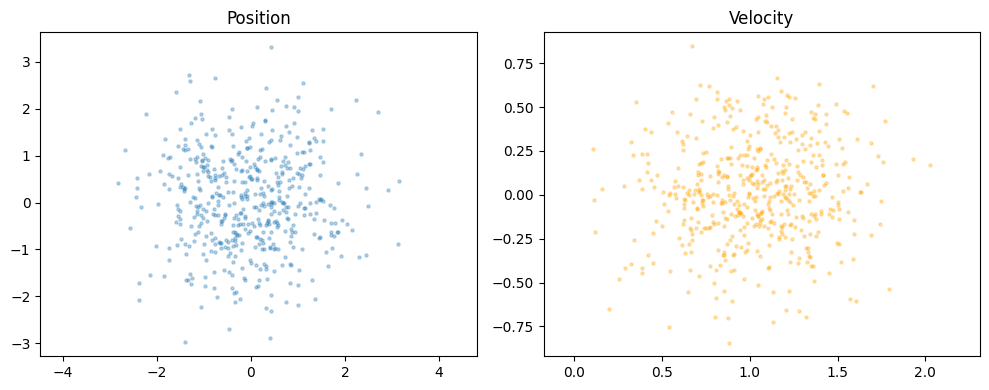

In [8]:
joint_mv = ProductDistribution(
    pos=MultivariateNormal(loc=jnp.zeros(2), cov=jnp.eye(2)),
    vel=MultivariateNormal(loc=jnp.array([1.0, 0.0]), cov=0.1 * jnp.eye(2)),
)
ss = joint_mv.sample_structured(sample_shape=(500,))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(ss['pos'][:, 0], ss['pos'][:, 1], alpha=0.3, s=5)
ax1.set_title("Position")
ax1.axis("equal")
ax2.scatter(ss['vel'][:, 0], ss['vel'][:, 1], alpha=0.3, s=5, color="orange")
ax2.set_title("Velocity")
ax2.axis("equal")
plt.tight_layout()
plt.show()

## from_distributions()

`ProductDistribution.from_distributions()` constructs a joint distribution from a list of named distributions. Each distribution must have a non-None `name` attribute, and names must be unique.

In [9]:
theta = Normal(loc=0.0, scale=1.0, name="theta")
sigma = Normal(loc=1.0, scale=0.5, name="sigma")
joint2 = ProductDistribution.from_distributions([theta, sigma])
print(f"Joint: {joint2}")
print(f"Components: {joint2.component_names}")

Joint: ProductDistribution(theta=Normal, sigma=Normal)
Components: ('theta', 'sigma')


## Conditioning

`joint.condition_on(name=value)` returns a new joint distribution over the **remaining (unconditioned) components**, representing $p(\text{unconditioned} \mid \text{conditioned} = \text{values})$. The conditioned components are removed from the result entirely.

For a `ProductDistribution` (independent components), the conditional is simply the marginal over the unconditioned components.

In [10]:
conditioned = joint.condition_on(theta=jnp.array(2.0))
print(f"Original components: {joint.component_names}")
print(f"After conditioning on theta=2.0: {conditioned.component_names}")
print(f"Event shape: {conditioned.event_shape}")

ss_cond = conditioned.sample_structured(sample_shape=(5,))
print(f"\nStructured keys (only unconditioned): {list(ss_cond.keys())}")
print(f"Sigma samples (still vary): {ss_cond['sigma']}")

Original components: ('theta', 'sigma')
After conditioning on theta=2.0: ('sigma',)
Event shape: (1,)

Structured keys (only unconditioned): ['sigma']
Sigma samples (still vary): [1.0588326  1.4438868  1.3457386  0.95113814 1.0989076 ]


In [11]:
def compute_product(theta: jnp.ndarray, sigma: jnp.ndarray) -> jnp.ndarray:
    return theta * sigma

w2 = Workflow(func=compute_product, n_broadcast_samples=200, vectorize="loop", seed=1)

# Without conditioning: both vary
result_free = w2(**joint.bind(theta='theta', sigma='sigma'))
print(f"Free mean: {float(jnp.mean(result_free.samples)):.3f}")

# With conditioning: theta fixed at 2, only sigma varies
# Since conditioned removes theta, we pass the fixed value directly
result_cond = w2(theta=jnp.array(2.0), sigma=conditioned['sigma'])
print(f"Conditioned mean (theta=2, sigma~N(1,0.5)): {float(jnp.mean(result_cond.samples)):.3f}")
print(f"Expected: ~{2 * 1.0:.1f}")

Free mean: 0.092
Conditioned mean (theta=2, sigma~N(1,0.5)): 2.031
Expected: ~2.0


## Log-Probability

For a `ProductDistribution`, `log_prob` on the flat representation equals the sum of component log-probs, since the components are independent.

In [12]:
x = jnp.array([0.5, 1.5])  # [theta_val, sigma_val]
lp_joint = joint.log_prob(x)
lp_sum = joint.components['theta'].log_prob(0.5) + joint.components['sigma'].log_prob(1.5)
print(f"Joint log_prob: {float(lp_joint):.4f}")
print(f"Sum of marginals: {float(lp_sum):.4f}")
print(f"Equal: {bool(jnp.isclose(lp_joint, lp_sum))}")

Joint log_prob: -1.7697
Sum of marginals: -1.7697
Equal: True


## 2. SequentialJointDistribution (Autoregressive Dependence)

`SequentialJointDistribution` models autoregressive dependence: later components are **callables** that receive earlier samples and return a `Distribution`. Components must be listed in topological order — each callable's parameters must refer to earlier component names.

In [13]:
# z is a root distribution; x depends on z; y depends on both z and x
seq = SequentialJointDistribution(
    z=Normal(loc=0.0, scale=1.0),
    x=lambda z: Normal(loc=z, scale=0.5),       # x | z ~ N(z, 0.5)
    y=lambda z, x: Normal(loc=z + x, scale=0.1), # y | z, x ~ N(z+x, 0.1)
)
print(f"Sequential joint: {seq}")
print(f"Components: {seq.component_names}")
print(f"Event shape: {seq.event_shape}")

Sequential joint: SequentialJointDistribution(z=Normal, x=<callable>, y=<callable>)
Components: ('z', 'x', 'y')
Event shape: (3,)


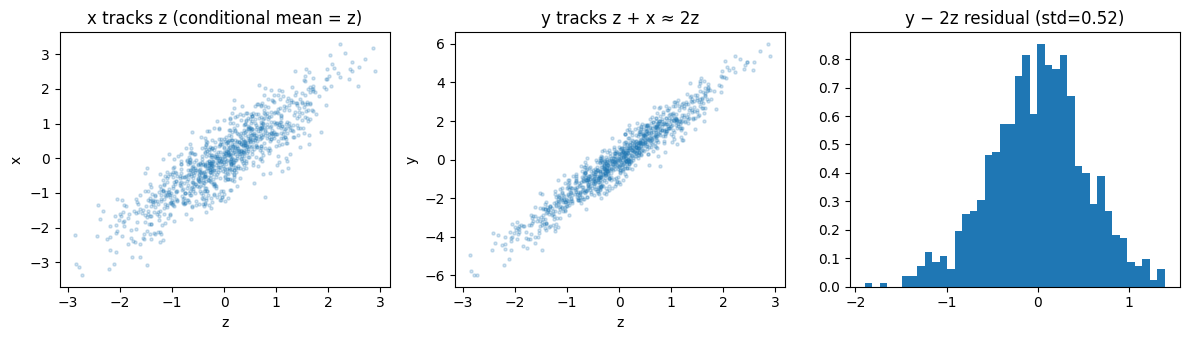

In [14]:
# Structured sampling shows autoregressive dependence
ss_seq = seq.sample_structured(sample_shape=(1000,))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].scatter(ss_seq['z'], ss_seq['x'], alpha=0.2, s=5)
axes[0].set_xlabel('z'); axes[0].set_ylabel('x')
axes[0].set_title('x tracks z (conditional mean = z)')

axes[1].scatter(ss_seq['z'], ss_seq['y'], alpha=0.2, s=5)
axes[1].set_xlabel('z'); axes[1].set_ylabel('y')
axes[1].set_title('y tracks z + x ≈ 2z')

# y ≈ z + x ≈ 2z, so residual y - 2z should be small
residual = ss_seq['y'] - 2 * ss_seq['z']
axes[2].hist(np.array(residual), bins=40, density=True)
axes[2].set_title(f'y − 2z residual (std={float(jnp.std(residual)):.2f})')
plt.tight_layout()
plt.show()

### Conditioning in Sequential Models

`condition_on()` returns a distribution over the **remaining unconditioned components**, representing $p(\text{unconditioned} \mid \text{conditioned} = \text{values})$. The conditioned components are removed from the result.

The **subtlety** is that conditioning on a non-root component does *not* give you a proper sampler for the posterior — forward sampling would draw ancestors from the **prior**, not the posterior $p(\text{ancestors} \mid \text{observed})$.

ProbPipe enforces this at sample time:
- **Root conditioning**: always sampleable (roots have no parents)
- **Non-root conditioning**: sampleable only if **all parents** of the conditioned component are also conditioned
- `log_prob()` always works regardless of sampleability (returns unnormalized conditional log-density)

In [15]:
# Case 1: Conditioning on a root — always sampleable
seq_cond_root = seq.condition_on(z=jnp.array(2.0))
print("Case 1: Condition on root z=2.0")
print(f"  Remaining components: {seq_cond_root.component_names}")
ss_cond = seq_cond_root.sample_structured(sample_shape=(500,))
print(f"  Structured keys: {list(ss_cond.keys())}  (z removed)")
print(f"  x|z=2 mean: {float(jnp.mean(ss_cond['x'])):.3f} (expected: 2.0)")
print(f"  y|z=2 mean: {float(jnp.mean(ss_cond['y'])):.3f} (expected: ~4.0)")

Case 1: Condition on root z=2.0
  Remaining components: ('x', 'y')


  Structured keys: ['x', 'y']  (z removed)
  x|z=2 mean: 2.007 (expected: 2.0)
  y|z=2 mean: 3.998 (expected: ~4.0)


In [16]:
# Case 2: Conditioning on a non-root with unconditioned parents — NOT sampleable
# x depends on z, so conditioning on x alone can't produce valid forward samples
# (z would be drawn from the prior, not from p(z|x))
seq_cond_nonroot = seq.condition_on(x=jnp.array(1.0))

print("Case 2: Condition on non-root x=1.0 (parent z is unconditioned)")
print(f"  Remaining components: {seq_cond_nonroot.component_names}")
try:
    seq_cond_nonroot.sample(sample_shape=(5,))
except NotImplementedError as e:
    print(f"  Sampling raises NotImplementedError:")
    print(f"  {e}")

# log_prob raises because the normalizing constant is intractable,
# but unnormalized_log_prob works — returns log p(z, y, x=1) up to a constant
flat = jnp.array([0.0, 1.0])  # z=0, y=1
try:
    seq_cond_nonroot.log_prob(flat)
except NotImplementedError as e:
    print(f"\n  log_prob raises: {type(e).__name__}")

ulp = seq_cond_nonroot.unnormalized_log_prob(flat)
print(f"  unnormalized_log_prob([z=0, y=1] | x=1) = {float(ulp):.4f}")

Case 2: Condition on non-root x=1.0 (parent z is unconditioned)
  Remaining components: ('z', 'y')
  Sampling raises NotImplementedError:
  Cannot sample from this SequentialJointDistribution: 'x' has unconditioned parent(s) ['z']. Forward sampling would draw these ancestors from the prior, not the posterior. Condition on the parent(s) as well, or use log_prob() to evaluate the density.

  log_prob raises: NotImplementedError
  unnormalized_log_prob([z=0, y=1] | x=1) = -1.7611


In [17]:
# Case 3: Conditioning on a non-root AND all its parents — sampleable
# If we also condition on z, then x's parent is fully observed,
# so forward sampling is valid.
seq_cond_both = seq.condition_on(z=jnp.array(1.0), x=jnp.array(2.0))
print("Case 3: Condition on z=1.0 AND x=2.0 (all parents of x are conditioned)")
print(f"  Remaining components: {seq_cond_both.component_names}")
ss_both = seq_cond_both.sample_structured(sample_shape=(500,))
print(f"  Structured keys: {list(ss_both.keys())}  (z and x removed)")
print(f"  y|z=1,x=2 mean: {float(jnp.mean(ss_both['y'])):.3f} (expected: ~3.0)")

Case 3: Condition on z=1.0 AND x=2.0 (all parents of x are conditioned)
  Remaining components: ('y',)
  Structured keys: ['y']  (z and x removed)
  y|z=1,x=2 mean: 3.002 (expected: ~3.0)


In [18]:
# Case 4: Chaining condition_on calls — sampleability accumulates
# First condition on x alone (not sampleable), then also on z (now sampleable)
step1 = seq.condition_on(x=jnp.array(1.5))
print("Case 4: Incremental conditioning")
print(f"  After condition_on(x=1.5): components = {step1.component_names}")
print(f"  Sampleable? ", end="")
try:
    step1.sample(sample_shape=(3,))
    print("yes")
except NotImplementedError:
    print("no (x's parent z is unconditioned)")

step2 = step1.condition_on(z=jnp.array(0.5))
print(f"  After also condition_on(z=0.5): components = {step2.component_names}")
print(f"  Sampleable? ", end="")
try:
    s = step2.sample(sample_shape=(3,))
    print(f"yes -> sample shape = {s.shape}  (only y remains)")
except NotImplementedError:
    print("no")

Case 4: Incremental conditioning
  After condition_on(x=1.5): components = ('z', 'y')
  Sampleable? no (x's parent z is unconditioned)
  After also condition_on(z=0.5): components = ('y',)
  Sampleable? 

yes -> sample shape = (3, 1)  (only y remains)


## 3. JointEmpirical (Weighted Joint Samples)

`JointEmpirical` stores per-component sample arrays with the same number of rows, plus optional weights. Sampling **resamples rows jointly**, preserving correlation between components. This is ideal for MCMC output or importance-weighted samples.

In [19]:
# Simulate correlated "posterior samples" (e.g. from MCMC)
key = jax.random.PRNGKey(42)
n_samples = 500
z_samples = jax.random.normal(key, (n_samples,))
x_samples = 0.8 * z_samples + 0.2 * jax.random.normal(jax.random.PRNGKey(1), (n_samples,))

je = JointEmpirical(z=z_samples, x=x_samples)
print(f"JointEmpirical: {je}")
print(f"Components: {je.component_names}")
print(f"n samples: {je.n}")
print(f"Uniform weights: {je.is_uniform}")
print(f"Mean: {je.mean()}")

JointEmpirical: JointEmpirical(z=EmpiricalDistribution, x=EmpiricalDistribution)
Components: ('z', 'x')
n samples: 500
Uniform weights: True
Mean: [-0.04694944 -0.03966558]


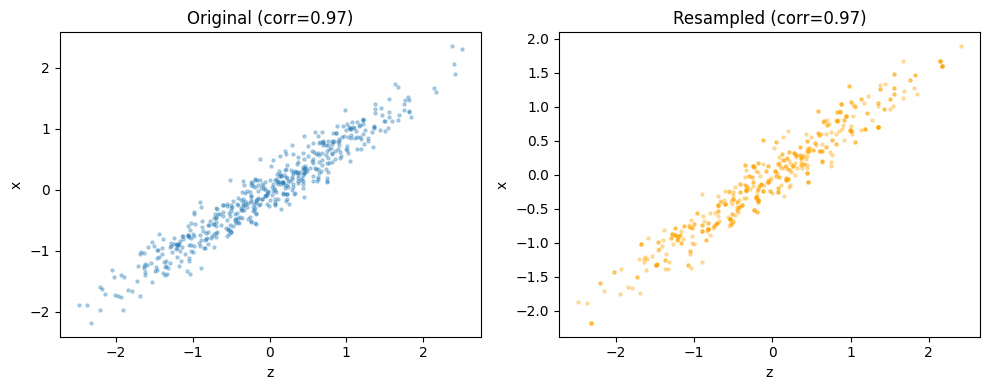

In [20]:
# Joint resampling preserves the correlation structure
resampled = je.sample_structured(sample_shape=(500,))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(np.array(z_samples), np.array(x_samples), alpha=0.3, s=5)
ax1.set_title(f'Original (corr={float(jnp.corrcoef(z_samples, x_samples)[0,1]):.2f})')
ax1.set_xlabel('z'); ax1.set_ylabel('x')

ax2.scatter(np.array(resampled['z']), np.array(resampled['x']), alpha=0.3, s=5, color='orange')
ax2.set_title(f'Resampled (corr={float(jnp.corrcoef(resampled["z"], resampled["x"])[0,1]):.2f})')
ax2.set_xlabel('z'); ax2.set_ylabel('x')
plt.tight_layout()
plt.show()

### Weighted Samples

Pass `weights` or `log_weights` to assign non-uniform importance to samples. This is useful for importance sampling output.

In [21]:
# Weighted JointEmpirical — e.g. importance sampling output
je_weighted = JointEmpirical(
    x=jnp.array([0.0, 1.0, 2.0, 3.0]),
    y=jnp.array([10.0, 20.0, 30.0, 40.0]),
    weights=jnp.array([0.01, 0.01, 0.08, 0.90]),  # heavily favor x=3, y=40
)
print(f"Uniform: {je_weighted.is_uniform}")
print(f"Weighted mean: {je_weighted.mean()}")
# Resampling reflects the weights
ws = je_weighted.sample_structured(sample_shape=(1000,))
print(f"Resampled x mean: {float(jnp.mean(ws['x'])):.2f} (expected ~2.9)")
print(f"Resampled y mean: {float(jnp.mean(ws['y'])):.2f} (expected ~39)")

Uniform: False
Weighted mean: [ 2.87 38.7 ]


Resampled x mean: 2.88 (expected ~2.9)
Resampled y mean: 38.80 (expected ~39)


## 4. JointGaussian (Analytical Cross-Covariance)

`JointGaussian` wraps a multivariate Gaussian with named blocks. Pass the full mean vector, covariance matrix, and component dimensions as keyword arguments. The key feature is **exact analytical conditioning** via `condition_on()`.

In [22]:
# A 2D Gaussian with correlated components x and y
cov = jnp.array([[1.0, 0.8],
                 [0.8, 1.0]])
jg = JointGaussian(
    mean=jnp.array([0.0, 0.0]),
    cov=cov,
    x=1,  # x is 1-dimensional
    y=1,  # y is 1-dimensional
)
print(f"JointGaussian: {jg}")
print(f"Components: {jg.component_names}")
print(f"Mean: {jg.mean()}")
print(f"Covariance:\n{jg.covariance}")

JointGaussian: JointGaussian(x=1, y=1)
Components: ('x', 'y')
Mean: [0. 0.]
Covariance:
[[1.  0.8]
 [0.8 1. ]]


### Exact Conditioning with `condition_on()`

`condition_on()` applies the standard Gaussian conditioning formulas to return a new `JointGaussian` over the remaining components:

$$\mu_{y|x} = \mu_y + \Sigma_{yx}\Sigma_{xx}^{-1}(x_{\text{obs}} - \mu_x), \quad \Sigma_{y|x} = \Sigma_{yy} - \Sigma_{yx}\Sigma_{xx}^{-1}\Sigma_{xy}$$

In [23]:
# Condition on x=2.0
cond = jg.condition_on(x=jnp.array([2.0]))
print(f"Conditional: {cond}")
print(f"Remaining components: {cond.component_names}")

# Analytical results: mu_y|x=2 = 0 + 0.8*1.0*2 = 1.6
#                     var_y|x   = 1 - 0.8^2 = 0.36
print(f"Conditional mean:     {float(cond.mean()[0]):.4f}  (expected 1.6)")
print(f"Conditional variance: {float(cond.variance()[0]):.4f}  (expected 0.36)")

# Draw samples and verify
cond_samples = cond.sample(sample_shape=(2000,))
print(f"\nSample mean:     {float(jnp.mean(cond_samples)):.3f}")
print(f"Sample variance: {float(jnp.var(cond_samples)):.3f}")

Conditional: JointGaussian(y=1)
Remaining components: ('y',)
Conditional mean:     1.6000  (expected 1.6)
Conditional variance: 0.3600  (expected 0.36)



Sample mean:     1.606
Sample variance: 0.350


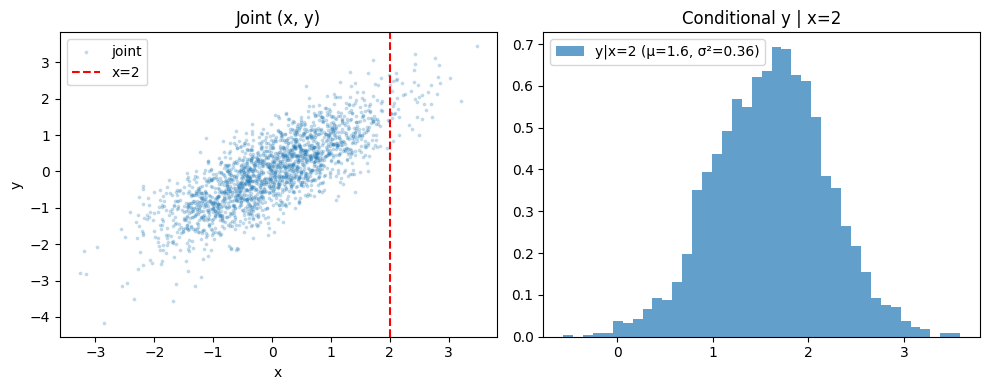

In [24]:
# Visualize: joint samples vs conditional slice
jg_samples = jg.sample(sample_shape=(2000,))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(np.array(jg_samples[:, 0]), np.array(jg_samples[:, 1]),
            alpha=0.2, s=3, label='joint')
ax1.axvline(2.0, color='red', linestyle='--', label='x=2')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('Joint (x, y)')
ax1.legend()

ax2.hist(np.array(cond_samples.ravel()), bins=40, density=True, alpha=0.7,
         label=f'y|x=2 (μ={float(cond.mean()[0]):.1f}, σ²={float(cond.variance()[0]):.2f})')
ax2.set_title('Conditional y | x=2')
ax2.legend()
plt.tight_layout()
plt.show()

### Multi-dimensional Components

`JointGaussian` supports multi-dimensional components. Component dimensions are specified as integers, and the sum must match the mean/covariance dimensions. You can condition on multiple components at once.

In [25]:
# 4D Gaussian: a (1D) + bc (2D) + d (1D)
jg4 = JointGaussian(
    mean=jnp.array([0.0, 1.0, 2.0, 3.0]),
    cov=jnp.eye(4),
    a=1, bc=2, d=1,
)
print(f"Components: {jg4.component_names}")
print(f"Event shape: {jg4.event_shape}")

# Condition on a and d, leaving bc
cond_bc = jg4.condition_on(a=jnp.array([0.0]), d=jnp.array([3.0]))
print(f"\nAfter conditioning on a=0, d=3:")
print(f"  Remaining components: {cond_bc.component_names}")
print(f"  Conditional mean: {cond_bc.mean()}")
print(f"  (Independent components, so conditioning doesn't shift the mean)")

Components: ('a', 'bc', 'd')
Event shape: (4,)



After conditioning on a=0, d=3:
  Remaining components: ('bc',)
  Conditional mean: [1. 2.]
  (Independent components, so conditioning doesn't shift the mean)


## Provenance Tracking

Every `condition_on()` call records its lineage — which joint distribution was conditioned and what values were observed. This enables tracing the full history of derived distributions.

In [26]:
# Conditioning on JointGaussian records provenance
cond_y = jg.condition_on(x=jnp.array([2.0]))
print(f"Source: {cond_y.source}")
print(f"Operation:   {cond_y.source.operation}")
print(f"Conditioned: {cond_y.source.metadata['conditioned']}")
print(f"Parent type: {type(cond_y.source.parents[0]).__name__}")

# Chain: condition_on twice on a SequentialJointDistribution
step1 = seq.condition_on(x=jnp.array(1.5))
step2 = step1.condition_on(z=jnp.array(0.5))
ancestors = provenance_ancestors(step2)
print(f"\nAncestors of double-conditioned dist: {[type(a).__name__ for a in ancestors]}")

# Serialization for logging/auditing
print(f"\nSerialized: {step2.source.to_dict()}")

Source: Provenance('condition_on', parents=[JointGaussian])
Operation:   condition_on
Conditioned: ['x']
Parent type: JointGaussian

Ancestors of double-conditioned dist: ['SequentialJointDistribution', 'SequentialJointDistribution']

Serialized: {'operation': 'condition_on', 'parents': [{'type': 'SequentialJointDistribution', 'name': None, 'source': {'operation': 'condition_on', 'parents': [{'type': 'SequentialJointDistribution', 'name': None}], 'metadata': {'conditioned': ['x']}}}], 'metadata': {'conditioned': ['z']}}


## Summary

| Type | Use Case | Key Feature |
|------|----------|-------------|
| `ProductDistribution` | Independent named components | `log_prob` = sum of marginals |
| `SequentialJointDistribution` | Autoregressive dependence | Callables receive earlier samples |
| `JointEmpirical` | MCMC / importance samples | Joint row resampling preserves correlation |
| `JointGaussian` | Analytical Gaussian models | Exact conditioning via `condition_on()` |

All types share:
- **`joint['name']`** -> `DistributionView` for correlated broadcasting
- **`sample_structured()`** -> dict of per-component arrays
- **`condition_on()`** -> returns $p(\text{unconditioned} \mid \text{conditioned} = \text{values})$ over remaining components only
- **`bind()`** -> remap component names to workflow arguments